In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv(r"C:\Users\HP\Downloads\cleanned.csv")
print(df.shape)
print(df.head())

(918, 11)
   age     sex              cp  trestbps   chol    fbs         restecg  \
0   63    Male  typical angina     145.0  233.0   True  lv hypertrophy   
1   67    Male    asymptomatic     160.0  286.0  False  lv hypertrophy   
2   67    Male    asymptomatic     120.0  229.0  False  lv hypertrophy   
3   37    Male     non-anginal     130.0  250.0  False          normal   
4   41  Female  typical angina     130.0  204.0  False  lv hypertrophy   

   thalch  exang  oldpeak  num  
0   150.0  False      2.3    0  
1   108.0   True      1.5    2  
2   129.0   True      2.6    1  
3   187.0  False      3.5    0  
4   172.0  False      1.4    0  


In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['cp'] = le.fit_transform(df['cp'])
df['restecg'] = le.fit_transform(df['restecg'])
df['fbs'] = df['fbs'].astype(int)
df['exang'] = df['exang'].astype(int)

print("Done! New dtypes:")
print(df.dtypes)

Done! New dtypes:
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalch      float64
exang         int64
oldpeak     float64
num           int64
dtype: object


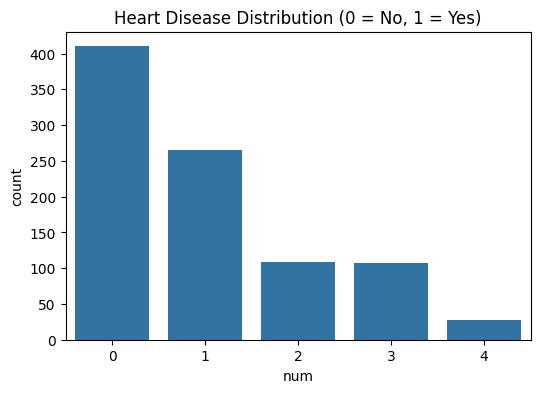

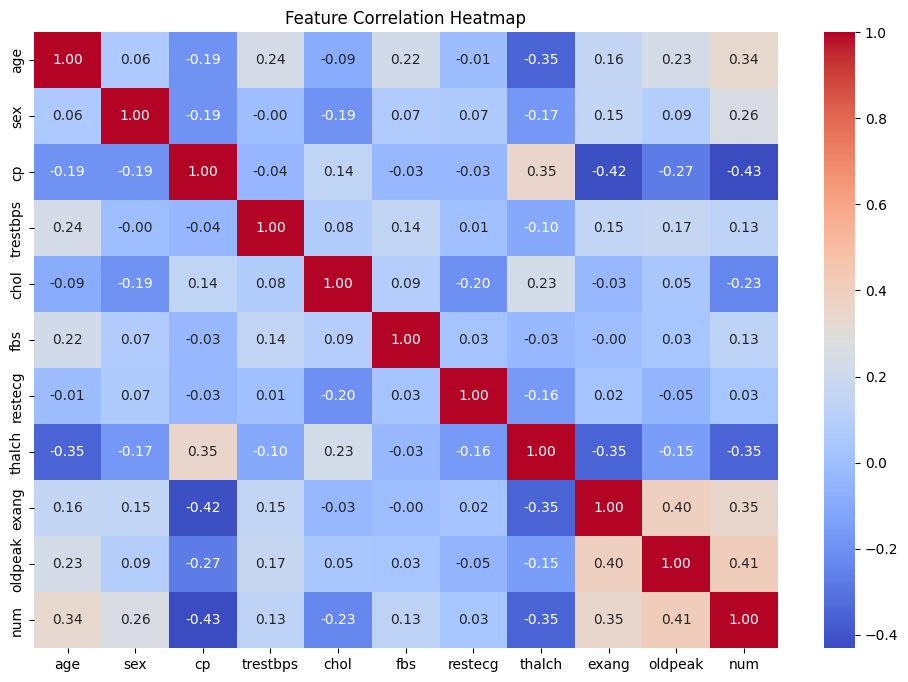

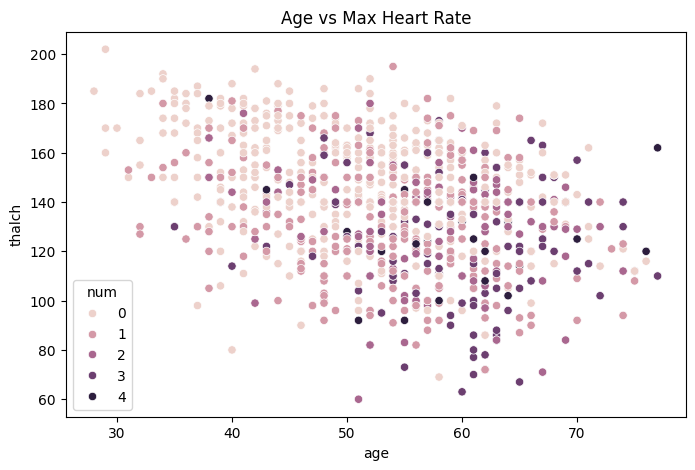

In [18]:
# Distribution of target variable
plt.figure(figsize=(6,4))
sns.countplot(x='num', data=df)
plt.title('Heart Disease Distribution (0 = No, 1 = Yes)')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Age vs Max Heart Rate colored by target
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='thalch', hue='num', data=df)
plt.title('Age vs Max Heart Rate')
plt.show()

In [19]:
# Split features and target
X = df.drop('num', axis=1)
y = df['num']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (734, 10)
Testing set size: (184, 10)


In [20]:
# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Logistic Regression Accuracy: 0.5543478260869565
Decision Tree Accuracy: 0.532608695652174


In [21]:
# Convert to binary (0 = No Disease, 1 = Disease)
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

print("Target value counts:")
print(df['num'].value_counts())

Target value counts:
num
1    508
0    410
Name: count, dtype: int64


In [22]:
# Split features and target
X = df.drop('num', axis=1)
y = df['num']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Logistic Regression Accuracy: 0.8043478260869565
Decision Tree Accuracy: 0.7717391304347826


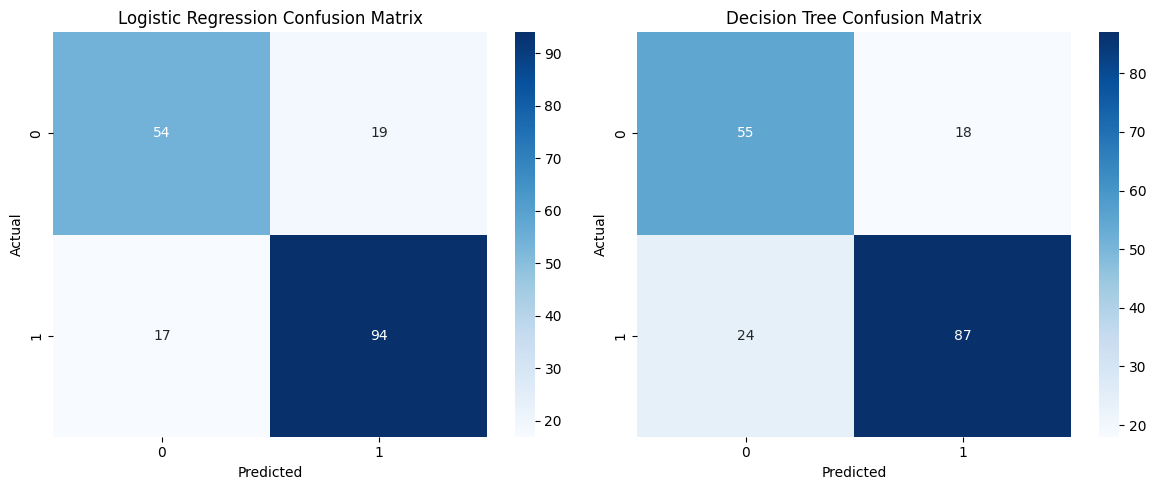

In [23]:
# Confusion Matrix for Logistic Regression
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

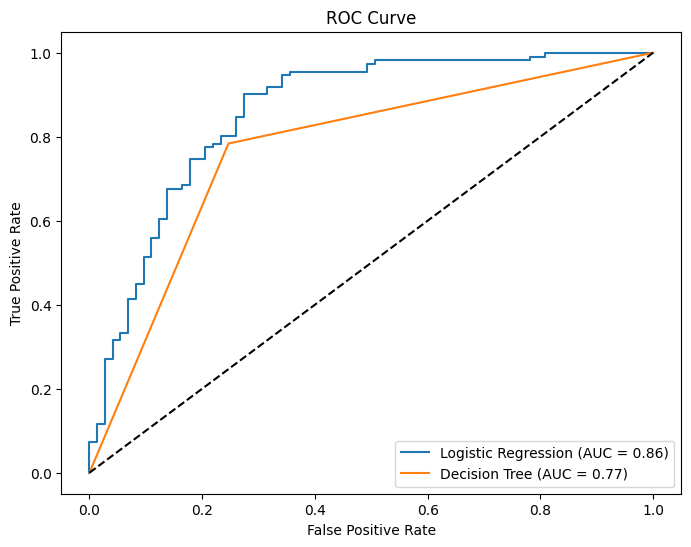

Logistic Regression AUC: 0.86
Decision Tree AUC: 0.77


In [24]:
# ROC Curve for both models
lr_prob = lr_model.predict_proba(X_test)[:,1]
dt_prob = dt_model.predict_proba(X_test)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)

plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f"Logistic Regression AUC: {lr_auc:.2f}")
print(f"Decision Tree AUC: {dt_auc:.2f}")

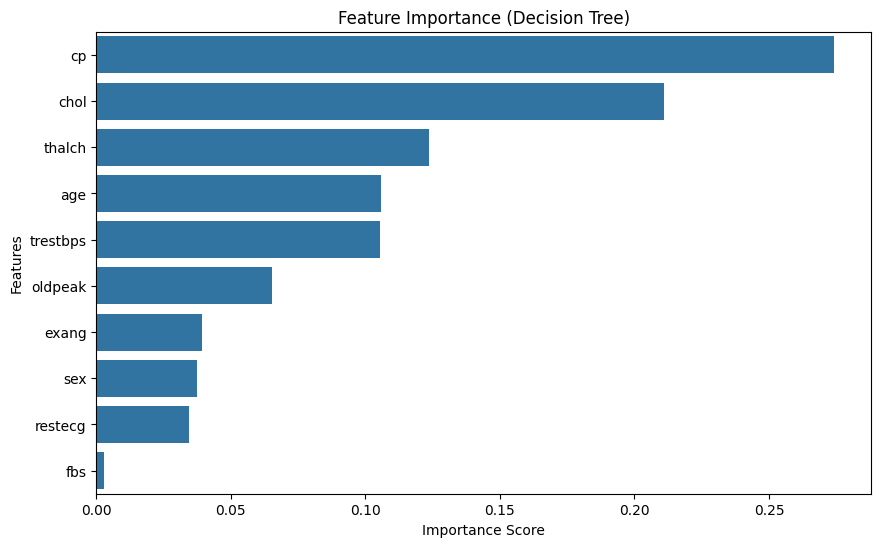

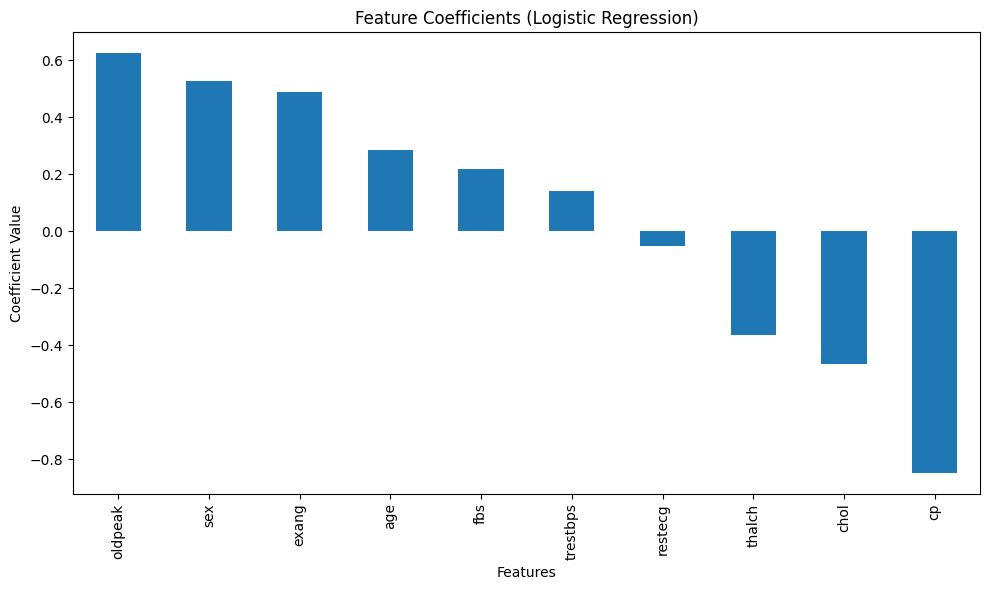

In [25]:
# Feature Importance using Decision Tree
feature_names = df.drop('num', axis=1).columns
importances = dt_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=feature_names[indices])
plt.title('Feature Importance (Decision Tree)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Logistic Regression Coefficients
coef = pd.Series(lr_model.coef_[0], index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(10,6))
coef.plot(kind='bar')
plt.title('Feature Coefficients (Logistic Regression)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [26]:
print("Logistic Regression Classification Report:")
print(classification_report(y_test, lr_pred))

print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.74      0.75        73
           1       0.83      0.85      0.84       111

    accuracy                           0.80       184
   macro avg       0.80      0.79      0.79       184
weighted avg       0.80      0.80      0.80       184

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.75      0.72        73
           1       0.83      0.78      0.81       111

    accuracy                           0.77       184
   macro avg       0.76      0.77      0.76       184
weighted avg       0.78      0.77      0.77       184

